# Caso 4 - Prediccion de Churn (Abandono de Clientes)

---

## Problema
Los clientes que abandonan silenciosamente son los mas costosos: adquirir un cliente nuevo cuesta entre 5 y 7 veces mas que retener uno existente. Sin un sistema predictivo, el equipo de retencion solo actua cuando el cliente ya se fue.

## Pregunta de Negocio
> **"Cuales de mis clientes actuales tienen alta probabilidad de abandonar la empresa en los proximos 90 dias?"**

## Objetivo
- Identificar a los clientes en riesgo ANTES de que se vayan.
- Segmentar por nivel de riesgo para priorizar acciones de retencion.
- Cuantificar el revenue en riesgo para que la gerencia pueda asignar presupuesto de retencion.

## Propuesta Tecnica
- Competencia de modelos de Clasificacion Binaria: Random Forest, XGBoost, Logistic Regression, Neural Network.
- Analisis de curvas ROC y matrices de confusion para seleccionar el campeon.
- Feature Importance para identificar los drivers del abandono.

## Dataset
Fuente: `TRAINING_DATASETS.OBT_CHURN_PREDICTION`
Features: `RANGO_EDAD`, `FEATURE_FRECUENCIA_HISTORICA`, `FEATURE_MONTO_GASTO_HISTORICO`, `FEATURE_RECENCIA_DIAS`
Target: `TARGET_ES_CHURN` (1 = abandono, 0 = activo)

---

## 1. Setup y Conexion

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import mlflow, mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

load_dotenv()
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print('[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db')

[OK] Entorno configurado. MLflow -> sqlite:///mlflow.db


In [2]:
conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='TRAINING_DATASETS'
)

try:
    df_raw = pd.read_sql('SELECT * FROM TRAINING_DATASETS.OBT_CHURN_PREDICTION', conn)
except Exception:
    df_raw = pd.read_sql('SELECT * FROM DBT_HGC_OBT.OBT_CHURN_PREDICTION', conn)

df_raw.columns = [c.upper() for c in df_raw.columns]
conn.close()

n_churn   = df_raw['TARGET_ES_CHURN'].sum()
n_total   = len(df_raw)
pct_churn = n_churn / n_total * 100

print(f'Dataset cargado : {n_total:,} clientes | {df_raw.shape[1]} columnas')
print(f'Clientes churn  : {n_churn:,} ({pct_churn:.1f}%)')
print(f'Clientes activos: {n_total - n_churn:,} ({100 - pct_churn:.1f}%)')
df_raw.head()

Dataset cargado : 300,000 clientes | 6 columnas
Clientes churn  : 103,705 (34.6%)
Clientes activos: 196,295 (65.4%)


,ID_CLIENTE_NK,RANGO_EDAD,FEATURE_FRECUENCIA_HISTORICA,FEATURE_MONTO_GASTO_HISTORICO,FEATURE_RECENCIA_DIAS,TARGET_ES_CHURN
0,290804.0,Mayor de 35,11,890.0,-29,0
1,235472.0,18 - 25,14,773.0,300,1
2,284335.0,Mayor de 35,10,1184.0,-193,0
3,125255.0,Mayor de 35,16,2672.0,-181,0
4,67956.0,Mayor de 35,16,1080.0,-215,0


## 2. EDA - Exploracion y Distribucion del Churn

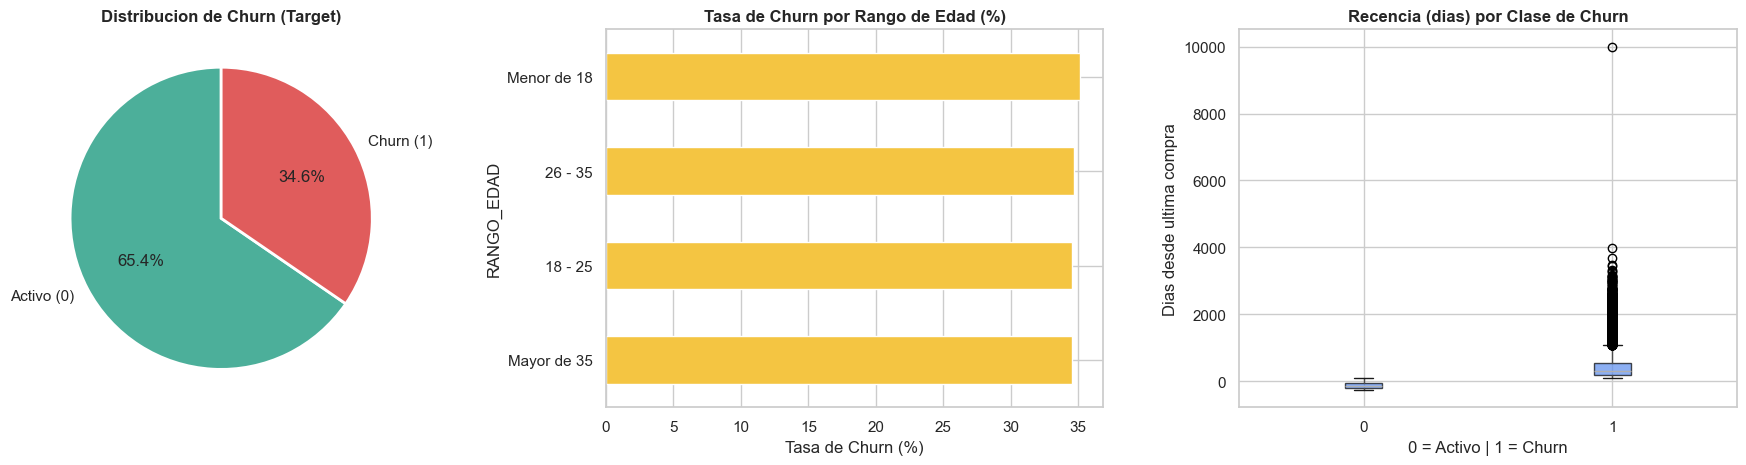

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribucion churn
labels = ['Activo (0)', 'Churn (1)']
counts = df_raw['TARGET_ES_CHURN'].value_counts().sort_index()
colors = ['#4CAF9A', '#E05C5C']
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Distribucion de Churn (Target)', fontweight='bold')

# Churn por rango de edad
churn_edad = df_raw.groupby('RANGO_EDAD')['TARGET_ES_CHURN'].mean() * 100
churn_edad.sort_values().plot(kind='barh', ax=axes[1], color='#F4C542', edgecolor='white')
axes[1].set_title('Tasa de Churn por Rango de Edad (%)', fontweight='bold')
axes[1].set_xlabel('Tasa de Churn (%)')

# Recencia vs Churn
df_raw.boxplot(column='FEATURE_RECENCIA_DIAS', by='TARGET_ES_CHURN', ax=axes[2],
               patch_artist=True,
               boxprops={'facecolor': '#5B8DEF', 'alpha': 0.7})
axes[2].set_title('Recencia (dias) por Clase de Churn', fontweight='bold')
axes[2].set_xlabel('0 = Activo | 1 = Churn')
axes[2].set_ylabel('Dias desde ultima compra')
plt.suptitle('')

plt.tight_layout()
plt.savefig('churn_eda.png', dpi=150, bbox_inches='tight')
plt.show()

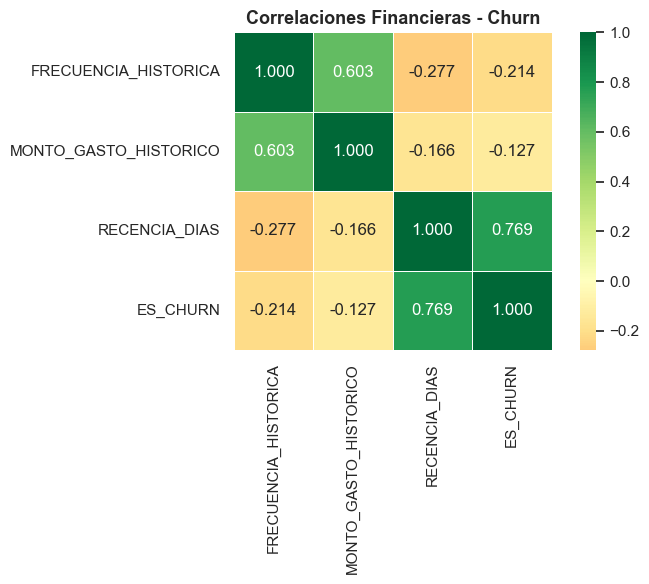


Correlacion de cada feature con el TARGET_ES_CHURN:
   FRECUENCIA_HISTORICA                -> -0.2141
   MONTO_GASTO_HISTORICO               -> -0.1270
   RECENCIA_DIAS                       -> +0.7694


In [4]:
NUM_COLS = ['FEATURE_FRECUENCIA_HISTORICA', 'FEATURE_MONTO_GASTO_HISTORICO',
            'FEATURE_RECENCIA_DIAS', 'TARGET_ES_CHURN']

corr = df_raw[NUM_COLS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5,
            xticklabels=[c.replace('FEATURE_','').replace('TARGET_','') for c in NUM_COLS],
            yticklabels=[c.replace('FEATURE_','').replace('TARGET_','') for c in NUM_COLS])
plt.title('Correlaciones Financieras - Churn', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('churn_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelacion de cada feature con el TARGET_ES_CHURN:')
corr_target = corr['TARGET_ES_CHURN'].drop('TARGET_ES_CHURN').sort_values()
for feat, val in corr_target.items():
    print(f'   {feat.replace("FEATURE_",""):<35} -> {val:+.4f}')

## 3. Competencia de Modelos de Clasificacion

In [5]:
FEAT_COLS = ['RANGO_EDAD', 'FEATURE_FRECUENCIA_HISTORICA',
             'FEATURE_MONTO_GASTO_HISTORICO', 'FEATURE_RECENCIA_DIAS']
TARGET    = 'TARGET_ES_CHURN'

X = df_raw[FEAT_COLS].copy()
y = df_raw[TARGET].copy()
X['RANGO_EDAD'] = X['RANGO_EDAD'].fillna('Desconocido')
X['FEATURE_FRECUENCIA_HISTORICA']   = X['FEATURE_FRECUENCIA_HISTORICA'].fillna(0)
X['FEATURE_MONTO_GASTO_HISTORICO']  = X['FEATURE_MONTO_GASTO_HISTORICO'].fillna(0)
X['FEATURE_RECENCIA_DIAS']          = X['FEATURE_RECENCIA_DIAS'].fillna(9999)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

cat_features = ['RANGO_EDAD']
num_features = ['FEATURE_FRECUENCIA_HISTORICA', 'FEATURE_MONTO_GASTO_HISTORICO', 'FEATURE_RECENCIA_DIAS']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

MODELS = {
    "LogisticRegression": LogisticRegression(random_state=42, max_iter=1000),
    "RandomForest":       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
    "XGBoost":            XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "NeuralNetwork":      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
}

mlflow.set_experiment("HGC_Churn_Notebook_Caso4")

resultados = {}
print(f"{'Modelo':<22} {'Accuracy':>10} {'AUC-ROC':>10}")
print("-" * 45)

for nombre, modelo in MODELS.items():
    with mlflow.start_run(run_name=nombre):
        pipeline = Pipeline([('pre', preprocessor), ('clf', modelo)])
        pipeline.fit(X_train, y_train)
        y_pred  = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else y_pred
        acc = accuracy_score(y_test, y_pred)
        auc_val = roc_auc_score(y_test, y_proba)
        mlflow.log_metrics({'accuracy': acc, 'auc_roc': auc_val})
        resultados[nombre] = {'pipeline': pipeline, 'acc': acc, 'auc': auc_val,
                               'y_pred': y_pred, 'y_proba': y_proba}
        print(f"  {nombre:<20} {acc:>10.4f} {auc_val:>10.4f}")

campeon_nombre = max(resultados, key=lambda m: resultados[m]['auc'])
campeon = resultados[campeon_nombre]
print(f"\nCAMPEON: {campeon_nombre}  (AUC={campeon['auc']:.4f}, Accuracy={campeon['acc']:.4f})")

Modelo                   Accuracy    AUC-ROC
---------------------------------------------


  LogisticRegression       0.9994     1.0000


  RandomForest             1.0000     1.0000


  XGBoost                  0.9987     1.0000


  NeuralNetwork            0.9992     1.0000

CAMPEON: LogisticRegression  (AUC=1.0000, Accuracy=0.9994)


## 4. Curvas ROC y Matriz de Confusion

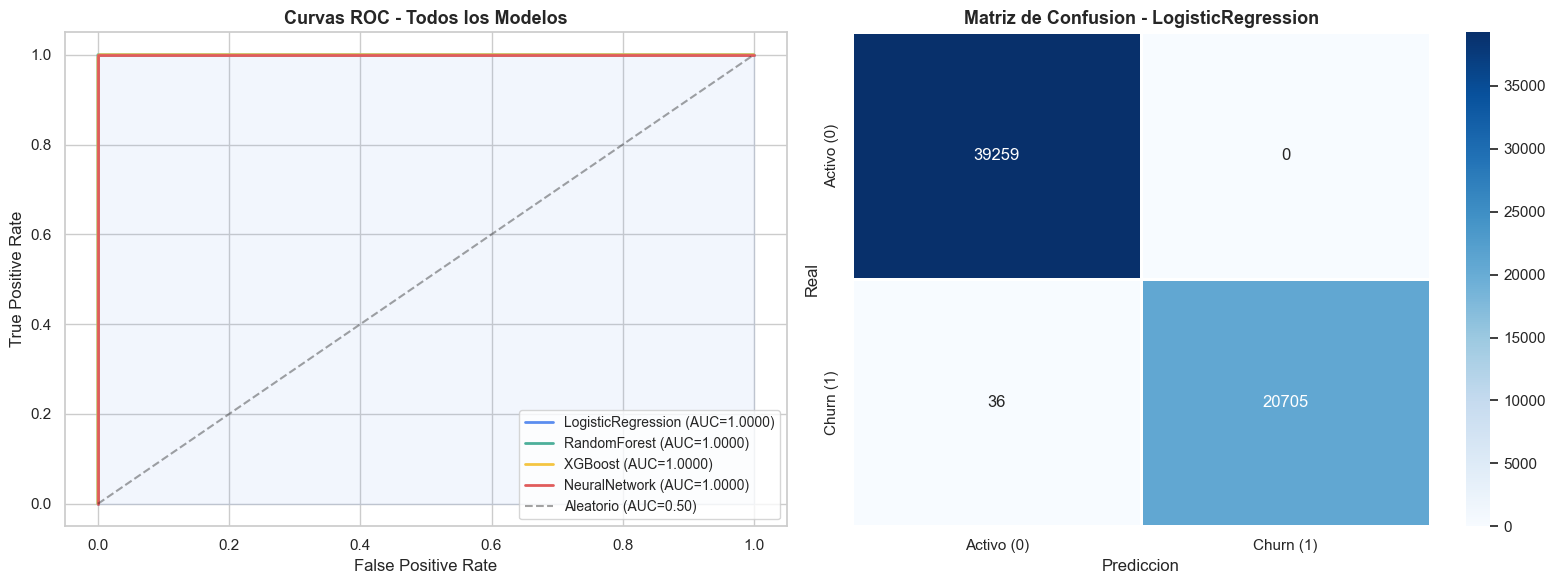


Reporte de Clasificacion - Campeon:
              precision    recall  f1-score   support

      Activo       1.00      1.00      1.00     39259
       Churn       1.00      1.00      1.00     20741

    accuracy                           1.00     60000
   macro avg       1.00      1.00      1.00     60000
weighted avg       1.00      1.00      1.00     60000



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Curvas ROC de todos los modelos
colores = ['#5B8DEF', '#4CAF9A', '#F4C542', '#E05C5C']
for (nombre, res), color in zip(resultados.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f'{nombre} (AUC={res["auc"]:.4f})')

axes[0].plot([0,1],[0,1],'k--', alpha=0.4, label='Aleatorio (AUC=0.50)')
axes[0].set_title('Curvas ROC - Todos los Modelos', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].fill_between(*roc_curve(y_test, campeon['y_proba'])[:2],
                     alpha=0.08, color='#5B8DEF')

# Matriz de confusion del campeon
cm = confusion_matrix(y_test, campeon['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Activo (0)', 'Churn (1)'],
            yticklabels=['Activo (0)', 'Churn (1)'],
            linewidths=1, linecolor='white')
axes[1].set_title(f'Matriz de Confusion - {campeon_nombre}', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('churn_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nReporte de Clasificacion - Campeon:')
print(classification_report(y_test, campeon['y_pred'],
                             target_names=['Activo', 'Churn']))

## 5. Feature Importance - Drivers del Abandono

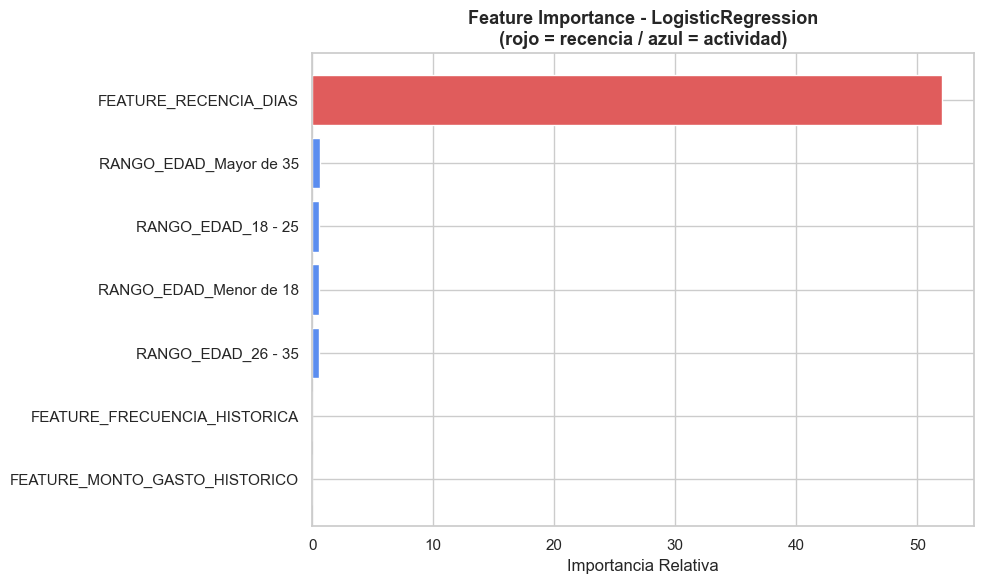

In [7]:
try:
    reg_model = campeon['pipeline'].named_steps['clf']
    pre       = campeon['pipeline'].named_steps['pre']

    if hasattr(reg_model, 'feature_importances_'):
        importances = reg_model.feature_importances_
    elif hasattr(reg_model, 'coef_'):
        importances = np.abs(reg_model.coef_[0])
    else:
        importances = None

    if importances is not None:
        cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(cat_features))
        all_names = num_features + cat_names
        fi_df = pd.DataFrame({'feature': all_names, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=True).tail(10)

        colores_fi = ['#E05C5C' if 'RECENCIA' in f else '#5B8DEF' for f in fi_df['feature']]

        plt.figure(figsize=(10, 6))
        plt.barh(fi_df['feature'], fi_df['importance'], color=colores_fi, edgecolor='white')
        plt.title(f'Feature Importance - {campeon_nombre}\n(rojo = recencia / azul = actividad)',
                  fontweight='bold', fontsize=13)
        plt.xlabel('Importancia Relativa')
        plt.tight_layout()
        plt.savefig('churn_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
except Exception as e:
    print(f'Feature Importance no disponible: {e}')

## 6. Segmentacion de Riesgo y Revenue en Peligro

In [8]:
df_result = df_raw[FEAT_COLS + [TARGET]].copy()
proba_churn = campeon['pipeline'].predict_proba(X)[:, 1]
df_result['PROBA_CHURN']   = proba_churn
df_result['RIESGO_NIVEL']  = pd.cut(proba_churn,
                                     bins=[0, 0.3, 0.6, 1.0],
                                     labels=['Bajo', 'Medio', 'Alto'])
df_result['RIESGO_NIVEL'] = df_result['RIESGO_NIVEL'].astype(str)
df_result['MONTO'] = df_raw['FEATURE_MONTO_GASTO_HISTORICO'].fillna(0).values

resumen = df_result.groupby('RIESGO_NIVEL').agg(
    clientes=('PROBA_CHURN', 'count'),
    revenue_en_riesgo=('MONTO', 'sum'),
    proba_promedio=('PROBA_CHURN', 'mean')
).reset_index()

print('\n' + '='*70)
print('  RESULTADOS: Caso 4 - Prediccion de Churn')
print('='*70)
print(f'  Clientes analizados  : {len(df_result):,}')
print(f'  Modelo campeon       : {campeon_nombre}')
print(f'  Accuracy             : {campeon["acc"]:.4f}')
print(f'  AUC-ROC              : {campeon["auc"]:.4f}')
print()

ACCIONES = {
    'Alto':  '[!] Llamada directa + oferta de retencion premium URGENTE',
    'Medio': '[~] Campana de re-engagement por email/WhatsApp',
    'Bajo':  '[v] Nutricion estandar - monitoreo mensual',
}

for _, row in resumen.sort_values('proba_promedio', ascending=False).iterrows():
    nivel = str(row['RIESGO_NIVEL'])
    accion = ACCIONES.get(nivel, '')
    print(f"  Riesgo {nivel.upper()}")
    print(f"     Clientes            : {row['clientes']:,} ({row['clientes']/len(df_result)*100:.1f}%)")
    print(f"     Revenue en riesgo   : Bs {row['revenue_en_riesgo']:,.0f}")
    print(f"     Prob. promedio      : {row['proba_promedio']:.1%}")
    print(f"     Accion              : {accion}")
    print()

print('='*70)


  RESULTADOS: Caso 4 - Prediccion de Churn
  Clientes analizados  : 300,000
  Modelo campeon       : LogisticRegression
  Accuracy             : 0.9994
  AUC-ROC              : 1.0000

  Riesgo ALTO
     Clientes            : 102,640 (34.2%)
     Revenue en riesgo   : Bs 100,958,659
     Prob. promedio      : 99.1%
     Accion              : [!] Llamada directa + oferta de retencion premium URGENTE

  Riesgo MEDIO
     Clientes            : 2,700 (0.9%)
     Revenue en riesgo   : Bs 2,809,130
     Prob. promedio      : 44.8%
     Accion              : [~] Campana de re-engagement por email/WhatsApp

  Riesgo BAJO
     Clientes            : 194,660 (64.9%)
     Revenue en riesgo   : Bs 217,581,890
     Prob. promedio      : 0.4%
     Accion              : [v] Nutricion estandar - monitoreo mensual



## 7. Instrucciones para Serving

El modelo Churn ya esta registrado en MLflow como `HGC_Churn_Model_Pro` y sirve en produccion.

```bash
# Desde hgc-ml/
python serve_churn.py
```

Expone el endpoint en `http://127.0.0.1:5001/invocations` que el backend (`ml.controller.js -> predictChurn`) utiliza.

**Payload esperado:**
```json
{
  "dataframe_split": {
    "columns": ["RANGO_EDAD","FEATURE_FRECUENCIA_HISTORICA","FEATURE_MONTO_GASTO_HISTORICO","FEATURE_RECENCIA_DIAS"],
    "data": [["26-35", 5, 850.0, 180]]
  }
}
```

> **Nota:** El frontend aplica ademas una heuristica dinamica de riesgo en tiempo real sobre los sliders para dar retroalimentacion inmediata antes de consultar la IA.